# Knickpoints & Landslides

In [15]:
import pip
pip.main(['install','geopandas'])

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Requirement already satisfied: geopandas in c:\users\edier\miniconda3\lib\site-packages (0.13.2)

Requirement already satisfied: fiona>=1.8.19 in c:\users\edier\miniconda3\lib\site-packages (from geopandas) (1.9.4.post1)

Requirement already satisfied: packaging in c:\users\edier\miniconda3\lib\site-packages (from geopandas) (23.0)

Requirement already satisfied: pandas>=1.1.0 in c:\users\edier\miniconda3\lib\site-packages (from geopandas) (2.0.3)

...

Requirement already satisfied: pytz>=2020.1 in c:\users\edier\miniconda3\lib\site-packages (from pandas>=1.1.0->geopandas) (2023.3)

Requirement already satisfied: tzdata>=2022.1 in c:\users\edier\miniconda3\lib\site-packages (from pandas>=1.1.0->geopandas) (2023.3)

Requirement already satisfied: numpy>=1.21.0 in c:\users\edier\miniconda3\lib\site-packages (from pandas>=1.1.0->geopandas) (1.25.1)

Requirement already satisfied: colorama in c:\users\edier\miniconda3\lib\site-packages (from click~=8.0->fiona>=1.8.19->geopandas) (0.4.6)

0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from math import ceil
import rasterio as rio
import matplotlib

## Rio Nechi

In [13]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/nechi_12m_network.csv')
#df1=df1[~((df1.distance<140000)&(df1.elevation>1100))]
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
70348896,0.0,54.349091,NaN,NaN,NaN,NaN
71141161,0.0,777.000000,NaN,NaN,NaN,NaN


In [14]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/nechi_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
21518,0.00000,61.576412,0.000000,0.461206
21517,17.67767,61.589191,0.000723,0.461204


In [ ]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/nechi_12m_knicpoint.csv')
df5=df5[df5.dz>200]
df5.head()

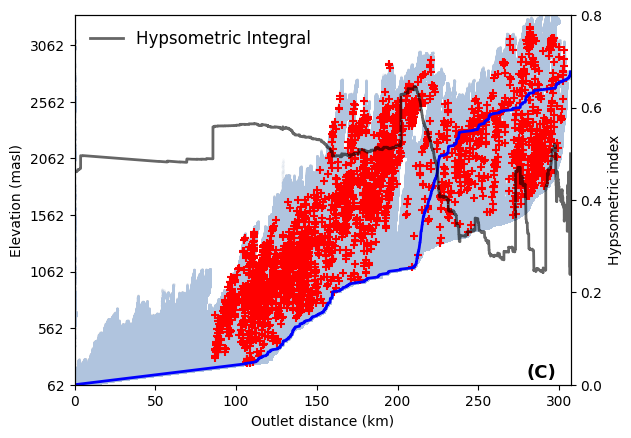

In [15]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",c='black',s=30,alpha=1,label='Relict landslides') # landslides
ax.set_ylim(min(df3.elevation),max(df3.elevation)+500)
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='black',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric Integral'); # hypsometric index
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*3,alpha=1,label='Knickpoints'); # knickpoints

#axin=ax.inset_axes([0.68,0.001,0.4,0.4])
#rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
#rec.plot(ax=axin,marker='+',color='red',markersize=1)
#rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
#rel.plot(ax=axin,marker='.',color='black',markersize=1)
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Vector/nechi_12m.shp")
#cat.plot(ax=axin,facecolor='none',linewidth=1,edgecolor='blue')
#axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index')
ax.set_yticks(np.arange(min(df3.elevation),max(df3.elevation)+500,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),50))
ax2.set_yticks(np.arange(0,1,0.2))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
#ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5), prop={'size': 10},frameon=False)
ax2.legend(ncol=1, loc="upper left",prop={'size': 12},frameon=False)
ax.text(280,120,'(C)',size=13,weight='bold')

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/nechi_12m_knickpoints2_.png", dpi=500);

## Q. La Iguana (cluster C)

In [34]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/iguana_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrec_d,Lrec_h,Lreld,Lrelh
329649,0.0,1486.006592,NaN,NaN,NaN,NaN
329646,12.5,1487.000000,NaN,NaN,NaN,NaN


In [35]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/iguana_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
1136,0.00000,1486.006592,0.000000,0.431922
1135,17.67767,1487.000000,0.056196,0.431610


In [49]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/iguana_12m_knicpoint.csv')
df5.head(2)

,x,y,z,dz,distance
0,428025.0625,699756.875,3094,73.203028,16307.095949
1,430612.5625,693831.875,1801,46.949153,7270.889245


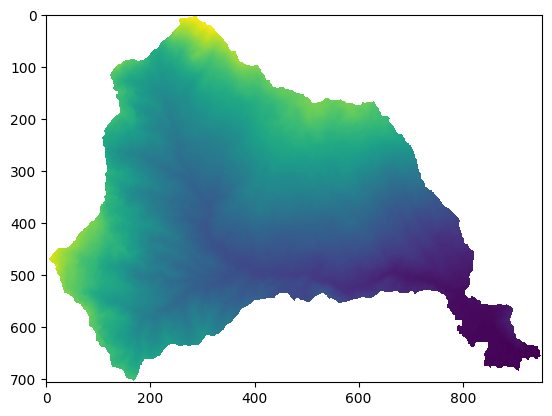

In [36]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/iguana_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [37]:
dx=(np.nanmax(alt_vector)-np.nanmin(alt_vector))/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

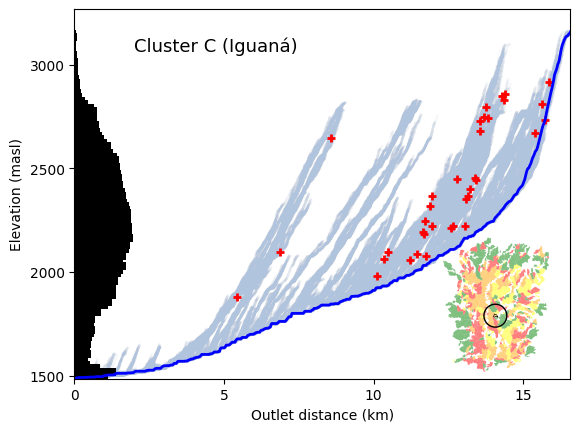

In [38]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrec_d/1000,df1.Lrec_h,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[100*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.65,0.0,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/iguana_12m.shp")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),5))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
#ax.legend(ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(min(df3.distance/1000)+2,max(df1.elevation)-100,'Cluster C (Iguaná)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/iguana_12m_knickpoints.png", dpi=500)

## Q. Dona Maria (cluster B)

In [28]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/donaMaria_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrec_d,Lrec_h,Lreld,Lrelh
471048,0.0,1560.009155,NaN,NaN,NaN,NaN
471038,12.5,1560.011353,NaN,NaN,NaN,NaN


In [29]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/donaMaria_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
1491,0.00000,1560.009155,0.000000,0.387581
1490,17.67767,1560.012207,0.000173,0.387600


In [9]:
#knickpoints
df5 = pd.read_excel('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/donamaria_12m.xlsx','Sheet5')
df5.head(2)

,x,y,z,dz,distance
0,424850.0625,692806.875,2639,66.722185,19975.751250
1,424662.5625,693406.875,2825,45.818082,20688.771632


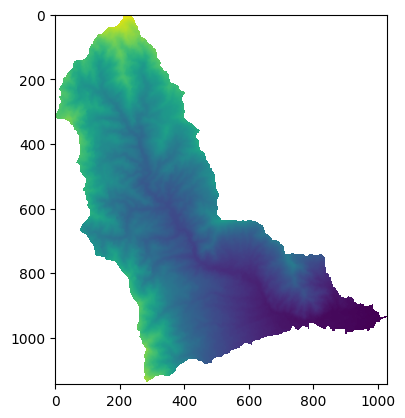

In [30]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/donaMaria_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [31]:
dx=(np.nanmax(alt_vector)-np.nanmin(alt_vector))/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

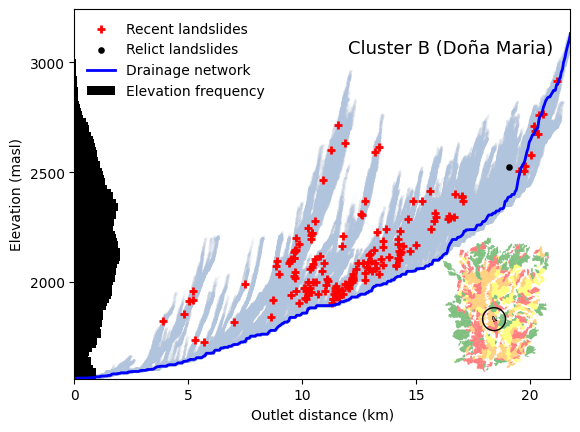

In [33]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrec_d/1000,df1.Lrec_h,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[100*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.65,0.0,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/donaMaria_12m.shp")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),5))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
ax.legend(ncol=1, loc="upper left",prop={'size': 10},frameon=False)
ax.text(12,max(df1.elevation)-100,'Cluster B (Doña Maria)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/donaMaria_12m_knickpoints.png", dpi=500)

### Rio Negro (Cluster A)

In [12]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/rionegro_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrec_d,Lrec_h
1913418,0.0,2127.0,NaN,NaN
871787,0.0,2415.0,NaN,NaN


In [14]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/rionegro_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
2569,0.0,2114.612793,0.000000,0.253136
2568,12.5,2114.614990,0.000176,0.253179


In [9]:
#knickpoints
df5 = pd.read_excel('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/donamaria_12m.xlsx','Sheet5')
df5.head(2)

,x,y,z,dz,distance
0,424850.0625,692806.875,2639,66.722185,19975.751250
1,424662.5625,693406.875,2825,45.818082,20688.771632


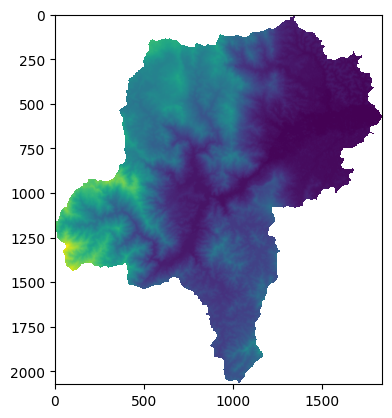

In [15]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nare/Raster/rionegro.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [16]:
dx=(np.nanmax(alt_vector)-np.nanmin(alt_vector))/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

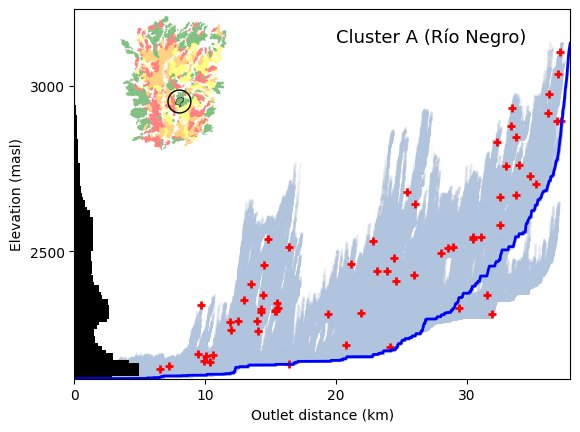

In [27]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrec_d/1000,df1.Lrec_h,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
#ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[100*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.0,0.6,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nare/Vector/rionegro.gpkg")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),10))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
#ax.legend(ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(20,max(df1.elevation),'Cluster A (Río Negro)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/rionegro_12m_knickpoints.png", dpi=500)

## Rio San Juan

In [21]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sanjuan_30m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
68431,0.0,3581.0,NaN,NaN,NaN,NaN
41026,0.0,3510.0,NaN,NaN,NaN,NaN


In [26]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sanjuan_30m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
1565,0.000000,568.912720,0.00000,0.394094
1566,29.993113,568.919312,0.00022,0.394098


In [28]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sanjuan_30m_knicpoint.csv')
df5.head(2)

,x,y,z,dz,distance
0,415933.534085,614934.271006,2587.0,90.718867,69207.282567
1,411614.061171,617363.713154,2005.0,63.753564,63498.048305


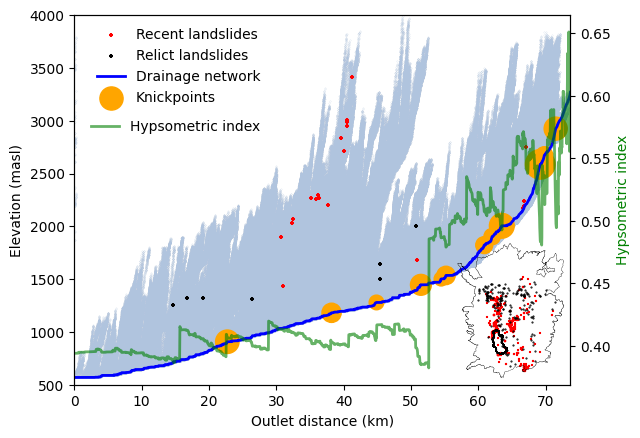

In [48]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.05,c='lightsteelblue',alpha=1) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",c='red',s=10,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker="+",c='black',s=10,alpha=1,label='Relict landslides') # landslides
ax.set_ylim(min(df3.elevation),max(df3.elevation))
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='green',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric index'); # hypsometric index
ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*5,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.68,0.001,0.4,0.4])
rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
rec.plot(ax=axin,marker='+',color='red',markersize=1)
rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
rel.plot(ax=axin,marker='.',color='black',markersize=1)
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/SanJuan/Vector/sanjuan.shp")
cat.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index',color='green')
ax.set_yticks(np.arange(500,4500,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),10))
ax2.set_yticks(np.arange(np.round(min(df3.hypso),1),np.round(max(df3.hypso),2)+0.02,0.05))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5),prop={'size': 10},frameon=False)
ax2.legend(ncol=1, bbox_to_anchor=(0, 0.25, 0.4, 0.5),prop={'size': 10},frameon=False)

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/sanjuan_30m_knickpoints.png")

## Q. Barroso (Cluster B)

In [66]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/barroso_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
1316818,0.0,628.018494,NaN,NaN,NaN,NaN
58194,0.0,2857.000000,NaN,NaN,NaN,NaN


In [67]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/barroso_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
2504,0.00000,628.018494,0.000000,0.403872
2503,17.67767,628.021606,0.000176,0.403876


In [72]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/barroso_12m_knicpoint.csv')
df5=df5[df5.dz>50]
df5.head(2)

,x,y,z,dz,distance
0,398851.8906,654652.625,1015,223.607463,4457.931996
1,381476.8906,666527.625,2775,193.191749,35037.288937


In [ ]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Cauca/Raster/tonusco_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

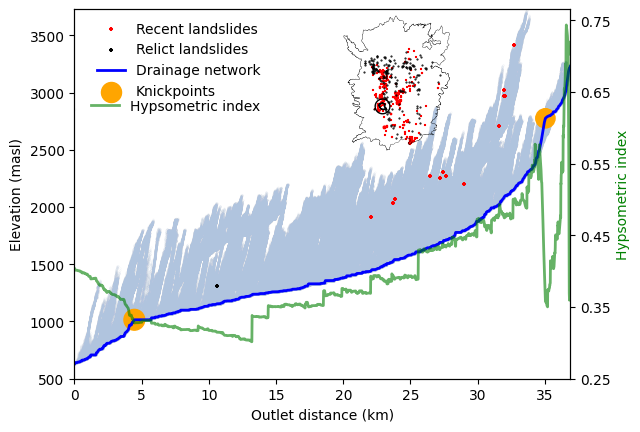

In [74]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",c='red',s=10,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker="+",c='black',s=10,alpha=1,label='Relict landslides') # landslides
ax.set_ylim(500,max(df3.elevation)+500)
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='green',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric index'); # hypsometric index
ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.45,0.6,0.4,0.4])
rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
rec.plot(ax=axin,marker='+',color='red',markersize=1)
rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
rel.plot(ax=axin,marker='.',color='black',markersize=1)
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/SanJuan/Vector/barroso_30m.gpkg")
cat.plot(ax=axin,facecolor='none',linewidth=1)
point=cat.centroid.buffer(20000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index',color='green')
ax.set_yticks(np.arange(500,max(df3.elevation)+500,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),5))
ax2.set_yticks(np.arange(0.25,0.8,0.1))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5),prop={'size': 10},frameon=False)
ax2.legend(ncol=1, bbox_to_anchor=(0, 0.29, 0.4, 0.5),prop={'size': 10},frameon=False);

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/barroso_12m_knickpoints.png")

## R. Sucio

In [9]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sucio_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
30854019,0.0,3657.005371,NaN,NaN,NaN,NaN
2244809,0.0,30.000000,NaN,NaN,NaN,NaN


In [10]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sucio_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
0,0.0,34.000000,0.000000,0.32439
1,12.5,34.002182,0.000175,0.32439


In [16]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/sucio_30m_knicpoint.csv')
df5=df5[df5.dz>40]
df5.head(2)

,x,y,z,dz,distance
0,379694.511633,739159.873993,1813.000000,159.492975,170134.751967
1,354976.746513,775637.151808,409.002167,58.303471,102230.705653


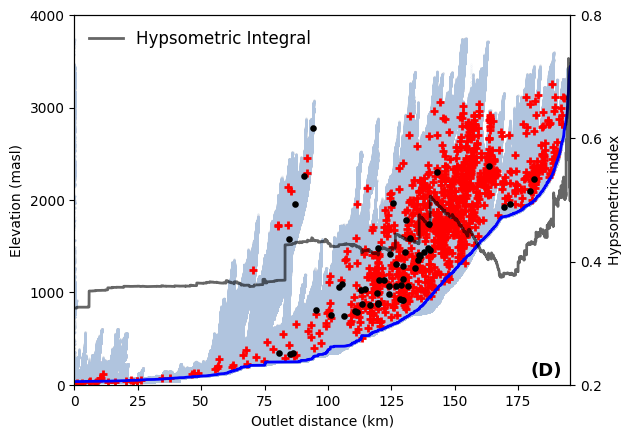

In [12]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides
ax.set_ylim(0,max(df3.elevation)+500)
ax2.set_ylim(0.2,0.8)
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='black',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric Integral'); # hypsometric index
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

#axin=ax.inset_axes([0.68,0.001,0.4,0.4])
#rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
#rec.plot(ax=axin,marker='+',color='red',markersize=1)
#rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
#rel.plot(ax=axin,marker='.',color='black',markersize=1)
#aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
#aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
#cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Sucio/Vector/sucio.shp")
#cat.plot(ax=axin,facecolor='none',linewidth=1)
#axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,1000))
ax.set_xticks(np.arange(0,max(df3.distance/1000),25))
ax2.set_yticks(np.arange(0.2,0.8,0.2))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
#ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5),prop={'size': 10},frameon=False)
ax2.legend(ncol=1,loc="upper left",prop={'size': 12},frameon=False)
ax.text(180,100,'(D)',size=13,weight='bold');

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/sucio_12m_knickpoints.png")

## R. Arma

In [86]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/arma_30m_network.csv')
#df1=df1[~((df1.distance<140000)&(df1.elevation>1100))]
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
680212,0.0,2208.000000,NaN,NaN,NaN,NaN
874567,0.0,2861.012939,NaN,NaN,NaN,NaN


In [87]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/arma_30m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
0,0.000000,610.252686,0.00000,0.491018
1,29.990975,610.259277,0.00022,0.491021


In [90]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/cuencas/arma_30m_knicpoint.csv')
df5=df5[df5.dz>50]
df5.head(2)

,x,y,z,dz,distance
0,463089.110817,615118.068259,2067.000000,373.274018,54505.178668
1,458050.627062,620907.886046,1330.003052,133.818129,43007.102118


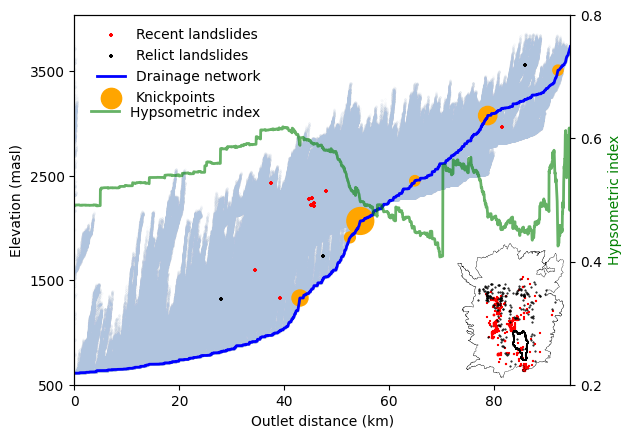

In [99]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",c='red',s=10,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker="+",c='black',s=10,alpha=1,label='Relict landslides') # landslides
ax.set_ylim(500,max(df3.elevation)+300)
ax2.set_ylim(0.2,0.8)
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='green',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric index'); # hypsometric index
ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.68,0.001,0.4,0.4])
rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
rec.plot(ax=axin,marker='+',color='red',markersize=1)
rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
rel.plot(ax=axin,marker='.',color='black',markersize=1)
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Arma/Vector/arma.shp")
cat.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index',color='green')
ax.set_yticks(np.arange(500,max(df3.elevation)+300,1000))
ax.set_xticks(np.arange(0,max(df3.distance/1000),20))
ax2.set_yticks(np.arange(0.2,0.8,0.2))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5),prop={'size': 10},frameon=False)
ax2.legend(ncol=1, bbox_to_anchor=(0, 0.29, 0.4, 0.5),prop={'size': 10},frameon=False);

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/arma_30m_knickpoints.png")

## Q. San Mateo (Cluster C)

In [100]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/sanmateo_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
425,0.0,2725.0,NaN,NaN,NaN,NaN
2004,0.0,2708.0,NaN,NaN,NaN,NaN


In [101]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/sanmateo_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
2279,0.0,530.662476,0.000000,0.42750
2280,12.5,530.664673,0.000176,0.42751


In [102]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/sanmateo_12m_knicpoint.csv')
df5=df5[df5.dz>50]
df5.head(2)

,x,y,z,dz,distance
0,400264.3906,686152.625,865,83.418336,7170.736829
1,384376.8906,691702.625,2962,70.317336,32135.333675


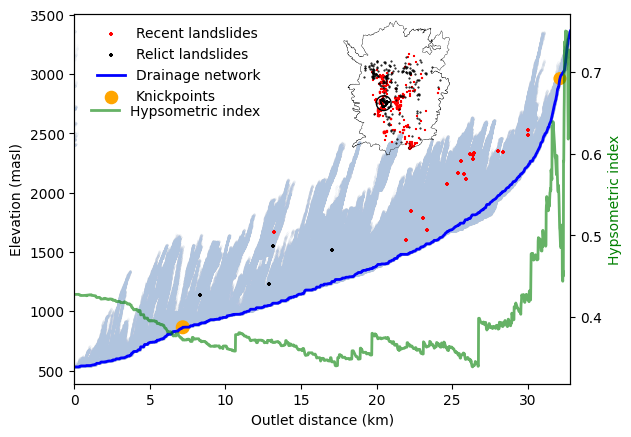

In [104]:
f, ax = plt.subplots()
ax2=ax.twinx()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",c='red',s=10,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker="+",c='black',s=10,alpha=1,label='Relict landslides') # landslides
#ax.set_ylim(500,max(df3.elevation)+500)
ax.set_xlim(0,max(df3.distance/1000))

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
ax2.plot(df3.distance/1000,df3.hypso,color='green',linewidth=2,linestyle='-',alpha=0.6,label='Hypsometric index'); # hypsometric index
ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.45,0.6,0.4,0.4])
rec=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/recent_utm.gpkg")
rec.plot(ax=axin,marker='+',color='red',markersize=1)
rel=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/relict_utm.gpkg")
rel.plot(ax=axin,marker='.',color='black',markersize=1)
aoi=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/Area_estudio_poligono.shp")
aoi.plot(ax=axin,facecolor='none',linewidth=0.2)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Cauca/Vector/sanmateo_30m.gpkg")
cat.plot(ax=axin,facecolor='none',linewidth=1)
point=cat.centroid.buffer(20000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax2.set_ylabel('Hypsometric index',color='green')
#ax.set_yticks(np.arange(500,max(df3.elevation)+500,500))
ax.set_xticks(np.arange(0,max(df3.distance/1000),5))
ax2.set_yticks(np.arange(0.4,0.8,0.1))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.legend(ncol=1, bbox_to_anchor=(0, 0.5, 0.4, 0.5),prop={'size': 10},frameon=False)
ax2.legend(ncol=1, bbox_to_anchor=(0, 0.29, 0.4, 0.5),prop={'size': 10},frameon=False);

#plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/sanmateo_12m_knickpoints.png")

## Q. Tonusco (cluster C)

In [87]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/tonusco_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
300249,0.0,2688.0,NaN,NaN,NaN,NaN
65846,0.0,2993.0,NaN,NaN,NaN,NaN


In [88]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/tonusco_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
3066,0.00000,468.215820,0.000000,0.469666
3065,17.67767,468.218903,0.000174,0.490784


In [111]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/tonusco_12m_knicpoint.csv')
df5=df5[df5.dz>30]
df5.head(2)

,x,y,z,dz,distance
0,396176.8906,731140.125,1741,75.302169,31135.118126
1,391014.3906,728102.625,2252,68.278712,38224.205423


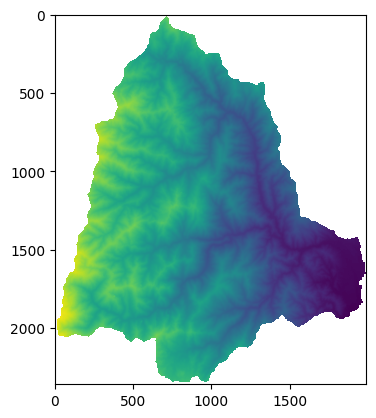

In [127]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Cauca/Raster/tonusco_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [129]:
dx=(np.nanmax(alt_vector)-np.nanmin(alt_vector))/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

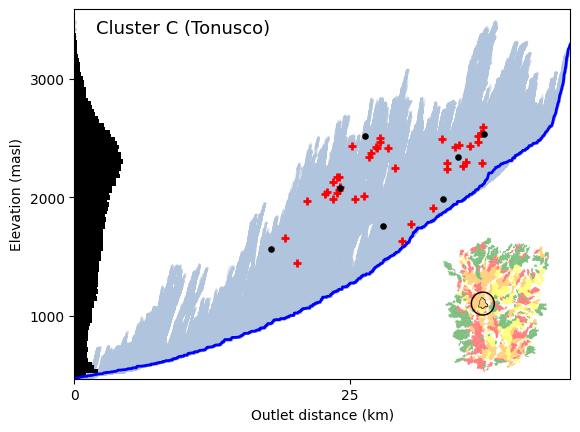

In [135]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drainage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[200*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.65,0.0,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Cauca/Vector/tonusco_30m.gpkg")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,1000))
ax.set_xticks(np.arange(0,max(df3.distance/1000),25))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
#ax.legend(ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(min(df3.distance/1000)+2,max(df1.elevation)-100,'Cluster C (Tonusco)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/tonusco_12m_knickpoints.png")

### Rio Guadalupe (cluster D)

In [4]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/guadalupe_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
2962257,0.0,693.147034,NaN,NaN,NaN,NaN
2961933,12.5,694.000000,NaN,NaN,NaN,NaN


In [5]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/guadalupe_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
4475,0.00000,693.147034,0.000000,0.666521
4474,17.67767,693.150146,0.000176,0.666528


In [6]:
#knickpoints
df5 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/guadalupe_12m_knicpoint.csv')
#df5=df5[df5.dz>30]
df5.head(2)

,x,y,z,dz,distance
0,472250.0625,749381.875,1791,744.847209,12639.633829
1,461850.0625,734444.375,2411,322.892165,39243.139405


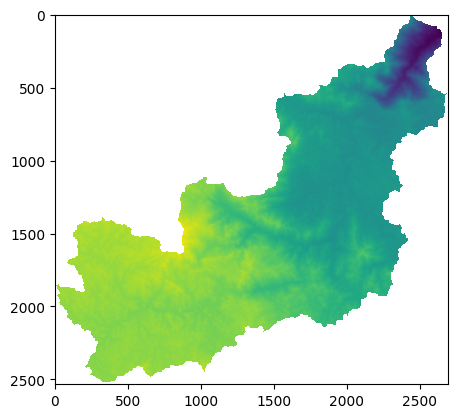

In [16]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Guadalupe/guadalupe_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

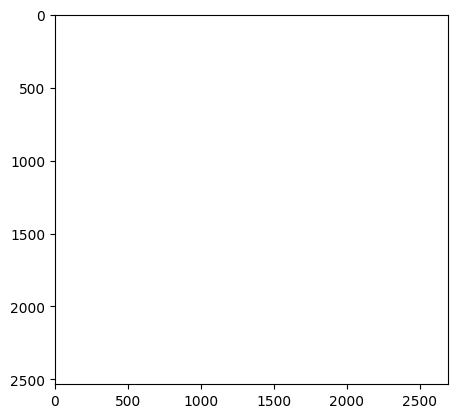

In [100]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Guadalupe/recent2_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-9999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [84]:
dx=(alt_vector.max()-alt_vector.min())/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

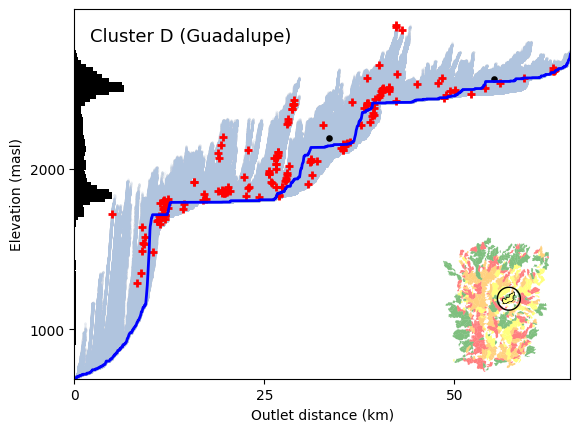

In [73]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[100*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.65,0.0,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Guadalupe/guadalupe2_12m.shp")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,1000))
ax.set_xticks(np.arange(0,max(df3.distance/1000),25))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
#ax.legend(ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(min(df3.distance/1000)+2,max(df1.elevation)-100,'Cluster D (Guadalupe)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/guadalupe_12m_knickpoints.png", dpi=500)

### Q. La Garcia (Cluster D)

In [74]:
#drainage network and landslide location
df1 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/garcia_12m_network.csv')
df1.sort_values(by='distance', inplace=True)
df1.head(2)

,distance,elevation,Lrecd,Lrech,Lreld,Lrelh
492713,0.0,1462.0,NaN,NaN,NaN,NaN
52249,0.0,3130.0,NaN,NaN,NaN,NaN


In [75]:
#main drinage and hypsometric index
df3 = pd.read_csv('G:/My Drive/INVESTIGACION/POSDOC/TopoToolbox/subcuencas/garcia_12m_main.csv')
df3.sort_values(by='distance', inplace=True)
df3.head(2)

,distance,elevation,gradient,hypso
1174,0.0,1448.041870,0.000000,0.549209
1173,12.5,1448.044067,0.000176,0.549451


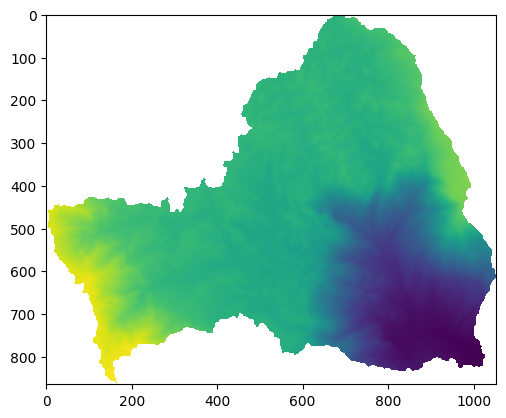

In [76]:
raster = rio.open('G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Raster/garcia2_12m.tif')
alt=raster.read(1)
alt=np.where(alt==-99999.,np.nan,alt)
alt_vector=alt.ravel()  # para pasarlo a un vector
plt.imshow(alt)

In [77]:
dx=(alt_vector.max()-alt_vector.min())/99
sorted_df = np.sort(alt_vector)
alt ={}
total=0
for x in sorted_df:
    if (pd.isna(x)):
        continue
    total+=1
    k = ceil(x+1)//dx
    alt.setdefault(k, []).append(x)
b = list(alt.values())

# calculate the mean, max, min, frequency
alt_mean=[]
alt_freq=[]
for x in range(len(b)):
  alt_mean.append(np.mean(b[x]))
  alt_freq.append(len(b[x]))

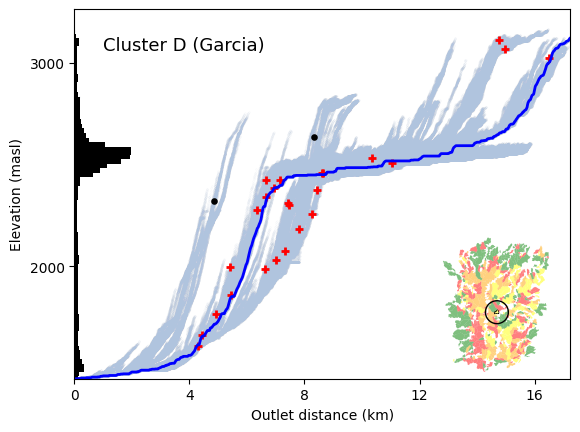

In [82]:
f, ax = plt.subplots()
ax.scatter(df1.distance/1000,df1.elevation,marker='.',s=0.02,c='lightsteelblue',alpha=0.6) # drinage network
ax.scatter(df1.Lrecd/1000,df1.Lrech,marker="+",linewidth=2,c='red',s=30,alpha=1,label='Recent landslides') # landslides
ax.scatter(df1.Lreld/1000,df1.Lrelh,marker=".",linewidth=2,c='black',s=30,alpha=1,label='Relict landslides') # landslides

frequency=[20*x/(total) for x in alt_freq]
ax.barh(alt_mean,frequency, height=40,color='black',label='Elevation frequency')

ax.plot(df3.distance/1000,df3.elevation,color='blue',linewidth=2,linestyle='-',label='Drainage network') #main drainage
#ax.scatter(df5.distance/1000,df5.z,marker='o',c='orange',s=df5.dz*2,alpha=1,label='Knickpoints'); # knickpoints

axin=ax.inset_axes([0.65,0.0,0.4,0.4])
color_discrete_map={"A": "green","B": "orange","C": "red","D": "yellow",}
cluster=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Data/Vector/catchment_cluster.gpkg")
cmap = matplotlib.colors.ListedColormap([color_discrete_map[b] for b in cluster.kmeans.unique()])
cluster.plot(ax=axin,column='kmeans',cmap=cmap,linewidth=0.2,alpha=0.5)
cat=gpd.read_file("G:/My Drive/INVESTIGACION/POSDOC/Nechi/Subcuencas/Aburra/Vector/garcia_12m.shp")
cat.plot(ax=axin,facecolor='none',linewidth=0.3)
point=cat.centroid.buffer(30000)
point.plot(ax=axin,facecolor='none',linewidth=1)
axin.set_axis_off()

ax.set_xlabel('Outlet distance (km)')
ax.set_ylabel('Elevation (masl)')
ax.set_yticks(np.arange(0,max(df3.elevation)+600,1000))
ax.set_xticks(np.arange(0,max(df3.distance/1000),4))
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=10)
ax.set_ylim(min(df3.elevation),max(df1.elevation)+100)
ax.set_xlim(0,max(df3.distance/1000))
#ax.legend(ncol=1, loc="lower right",prop={'size': 10},frameon=False)
ax.text(min(df3.distance/1000)+1,max(df1.elevation)-100,'Cluster D (Garcia)',size=13);

plt.savefig("G:/My Drive/INVESTIGACION/POSDOC/Figuras/garcia_12m_knickpoints.png", dpi=500)

### Rio Cocorna (Cluster D)

### Rio Cartama (Cluster D)

### Q, La Mosca (Cluster A)

### Rio Negro (Cluster A)

### Rio Rayo (Cluster A)

### Rio Tamaná (Cluster A)

### Rio Chibugado (Cluster A)